# Notebook 4: Portfolio Construction Module
### NIFTY-50 Investment Intelligence — Mandatory Task B

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from src.portfolio import (get_price_data, build_all_portfolios, save_portfolios,
                            load_portfolios, simulate_portfolio_performance,
                            compute_efficient_frontier, get_sector_exposure)
from src.data_loader import get_sector_map

os.makedirs('../report', exist_ok=True)
os.makedirs('../models', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
print("Imports OK")

Imports OK


## 1. Load Data & Build All Portfolios

In [2]:
prices = get_price_data(start_date='2015-01-01')
print(f"Price matrix: {prices.shape}  ({prices.index[0].date()} → {prices.index[-1].date()})")

portfolios = build_all_portfolios(prices)
save_portfolios(portfolios)

print("\nPortfolio Summary:")
print(f"{'Profile':<22} {'Strategy':<30} {'Return':>8} {'Vol':>7} {'Sharpe':>8} {'# Holdings':>11}")
print("-" * 90)
for name, p in portfolios.items():
    n = len(p['weights'])
    print(f"{p['label']:<22} {p['strategy']:<30} {p['expected_annual_return']*100:>7.1f}%  {p['annual_volatility']*100:>6.1f}%  {p['sharpe_ratio']:>8.3f}  {n:>10}")

Price matrix: (1566, 48)  (2015-01-01 → 2021-04-30)
Building Conservative portfolio (Min Volatility)...
Building Balanced portfolio (Max Sharpe)...
Building Aggressive portfolio (Max Return)...
Building Risk Parity portfolio...
Building Equal Weight benchmark...
Portfolios saved to c:\Users\mailg\Desktop\investment-intelligence-nifty50\models\portfolios.json

Portfolio Summary:
Profile                Strategy                         Return     Vol   Sharpe  # Holdings
------------------------------------------------------------------------------------------
Conservative Investor  Minimum Volatility                 5.6%    14.3%     0.040          21
Balanced Investor      Maximum Sharpe Ratio              22.5%    18.5%     0.945           9
Aggressive Investor    Maximum Return (Risk-Capped)      28.3%    22.7%     1.029           4
Risk Parity            Risk Parity                       10.9%    17.8%     0.330          48
Equal Weight           Equal Weight (Benchmark)          10.

## 2. Portfolio Weights Visualisation

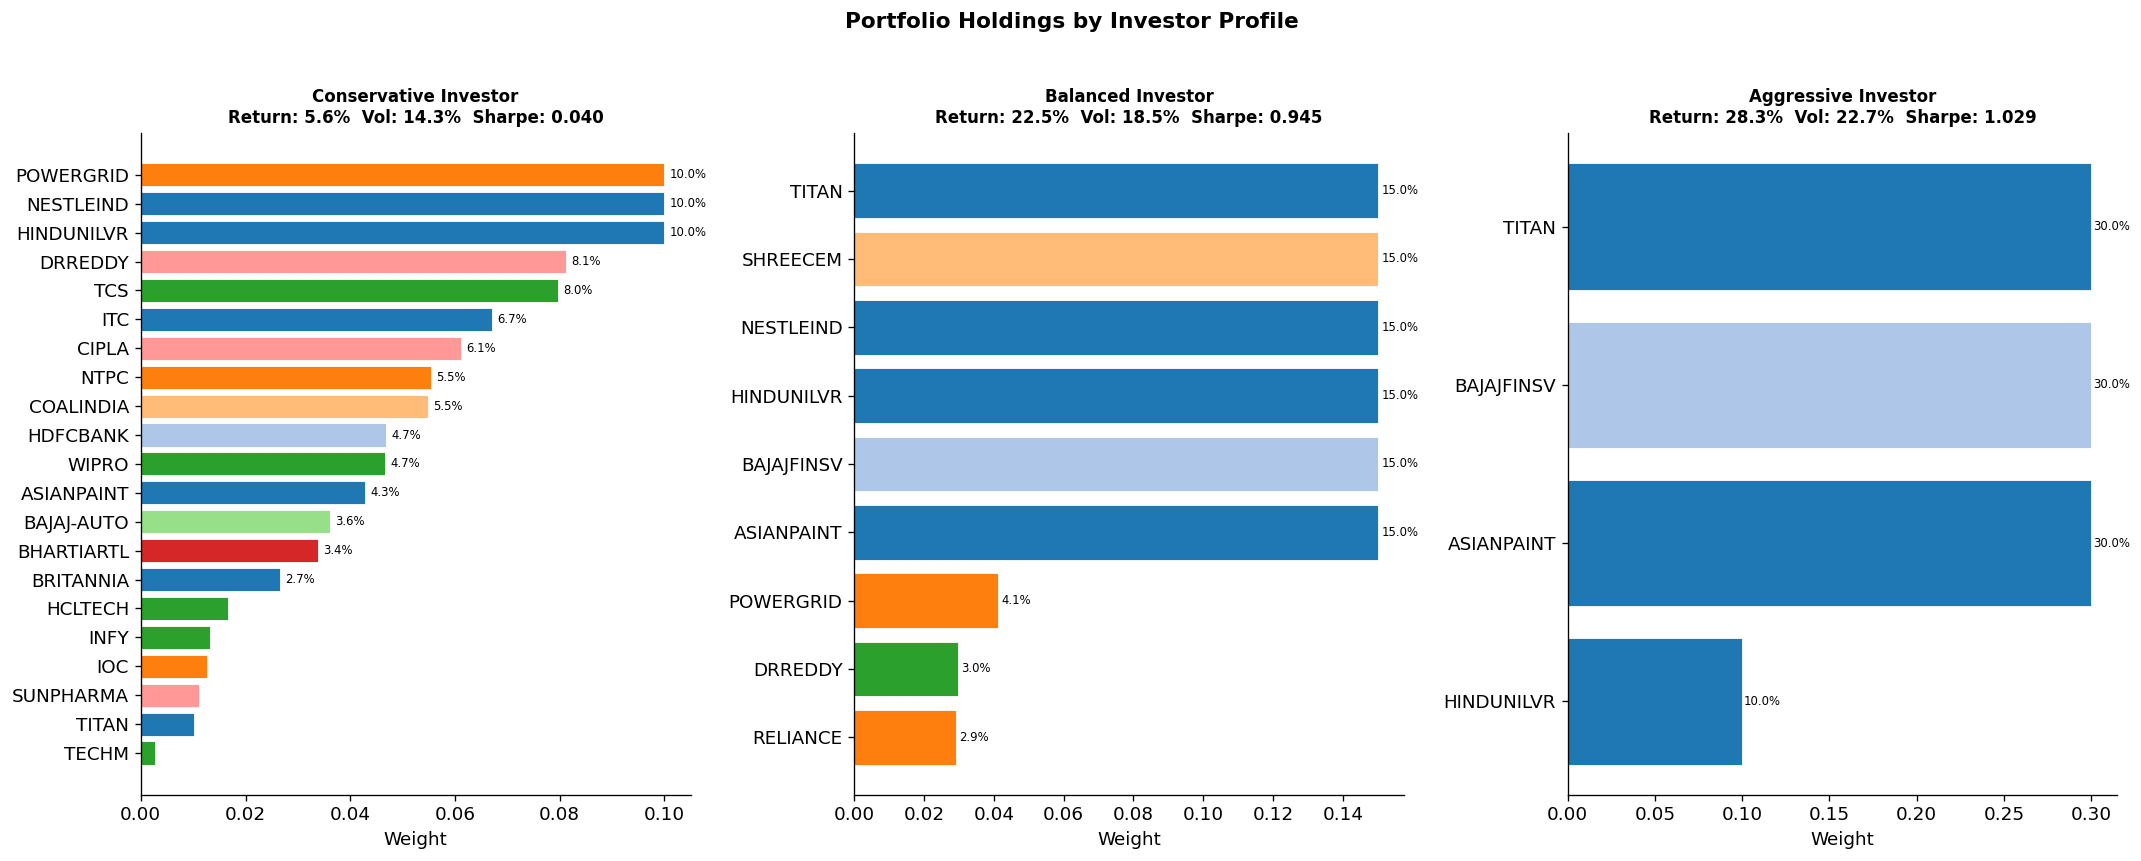

In [3]:
sector_map = get_sector_map()
profile_order = ['conservative', 'balanced', 'aggressive']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, name in zip(axes, profile_order):
    p = portfolios[name]
    weights = dict(sorted(p['weights'].items(), key=lambda x: x[1]))  # ascending
    syms = list(weights.keys())
    vals = list(weights.values())

    sectors = [sector_map.get(s, 'Unknown') for s in syms]
    unique_sectors = list(set(sectors))
    palette = plt.cm.tab20.colors
    sector_color = {s: palette[i % 20] for i, s in enumerate(unique_sectors)}
    bar_colors = [sector_color[s] for s in sectors]

    bars = ax.barh(syms, vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel("Weight")

    title_str = (f"{p['label']}\n"
                 f"Return: {p['expected_annual_return']*100:.1f}%  "
                 f"Vol: {p['annual_volatility']*100:.1f}%  "
                 f"Sharpe: {p['sharpe_ratio']:.3f}")
    ax.set_title(title_str, fontsize=10, fontweight='bold')

    for bar, val in zip(bars, vals):
        if val > 0.02:
            ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                    f'{val*100:.1f}%', va='center', fontsize=7)

plt.suptitle("Portfolio Holdings by Investor Profile", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/portfolio_weights.png', bbox_inches='tight')
plt.show()

## 3. Sector Exposure Comparison

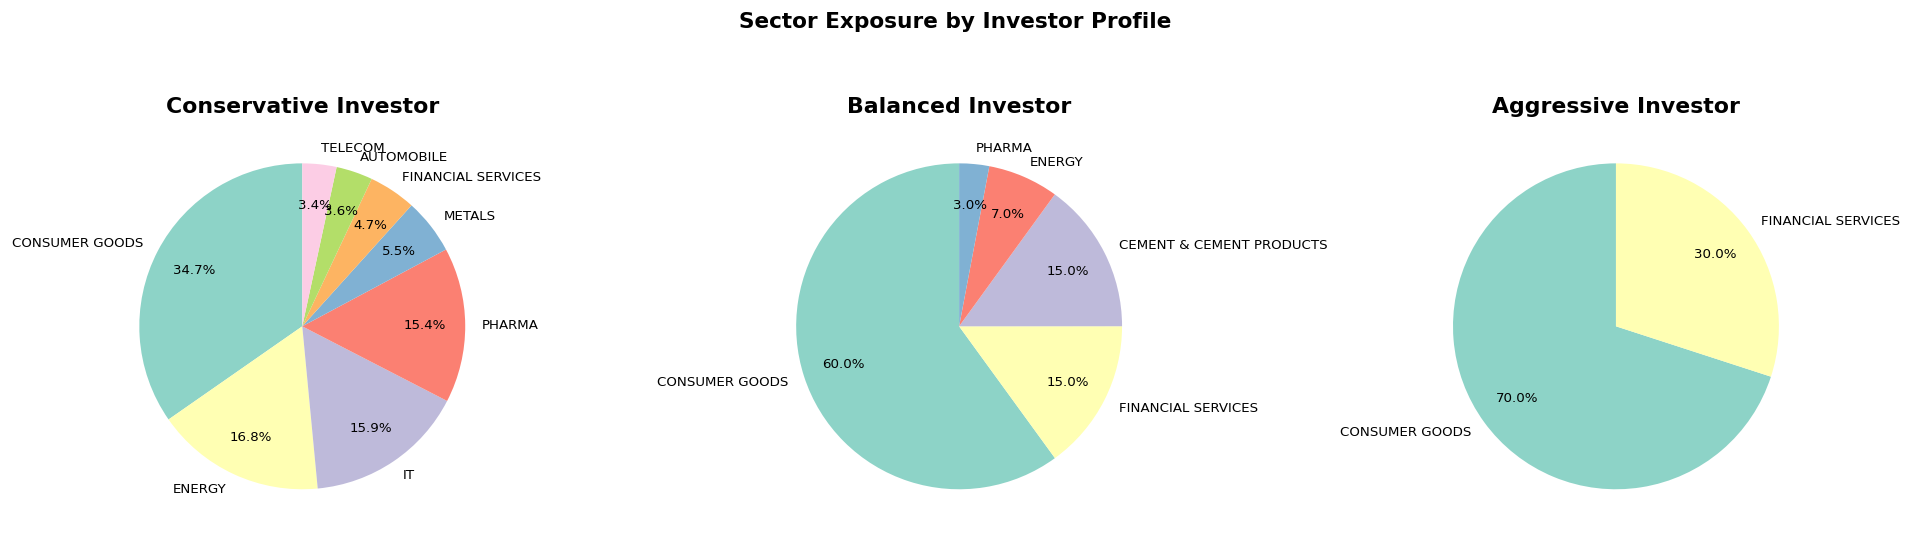

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, name in zip(axes, profile_order):
    p = portfolios[name]
    exposure = get_sector_exposure(p['weights'], sector_map)
    sectors  = list(exposure.keys())
    values   = [v * 100 for v in exposure.values()]
    palette  = plt.cm.Set3.colors
    ax.pie(values, labels=sectors, colors=palette[:len(sectors)],
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8},
           pctdistance=0.75)
    ax.set_title(f"{p['label']}", fontweight='bold')

plt.suptitle("Sector Exposure by Investor Profile", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/sector_exposure.png', bbox_inches='tight')
plt.show()

## 4. Historical Performance Simulation

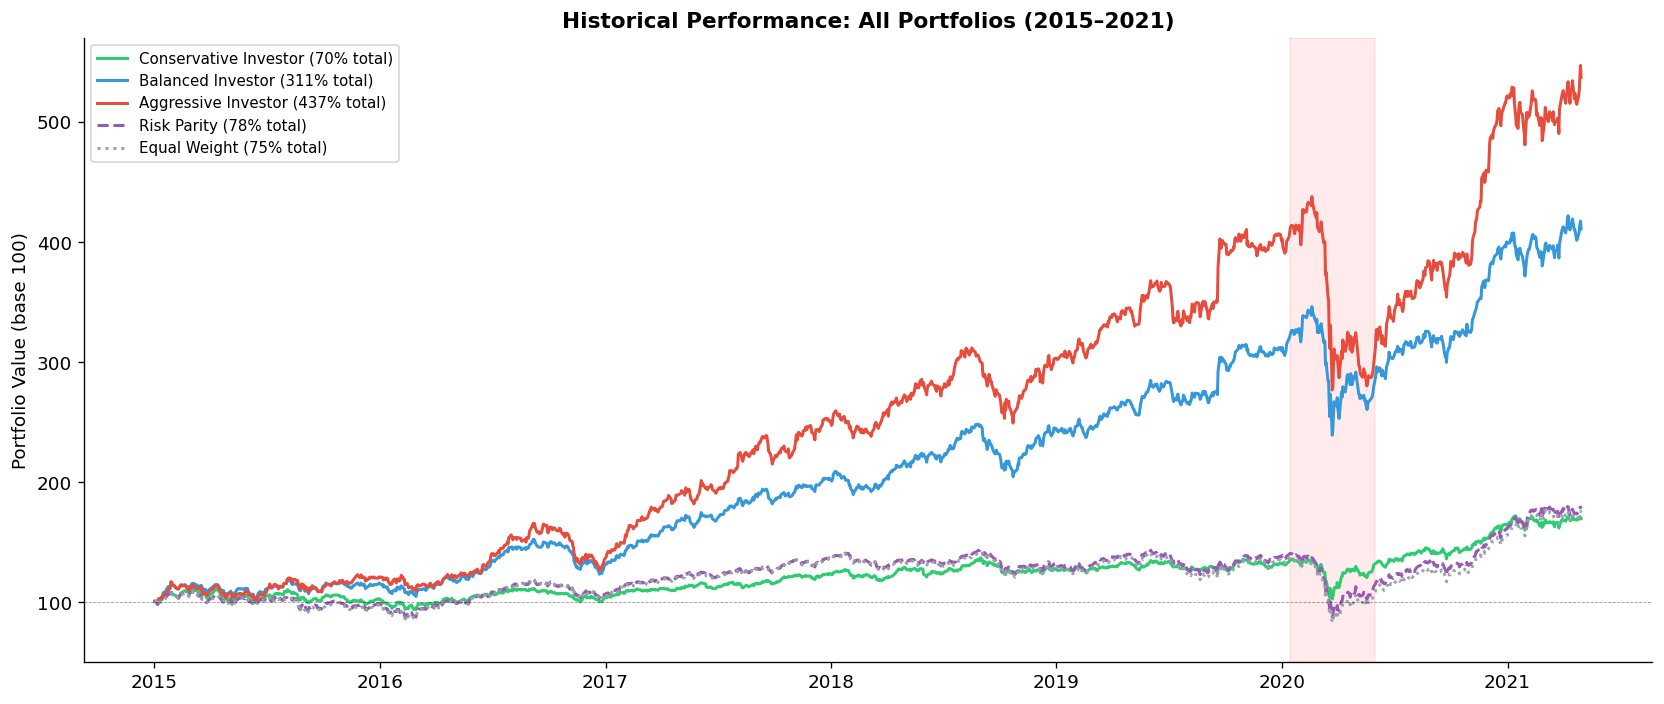

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

plot_configs = [
    ('conservative', '#2ecc71', '-'),
    ('balanced',     '#3498db', '-'),
    ('aggressive',   '#e74c3c', '-'),
    ('risk_parity',  '#9b59b6', '--'),
    ('equal_weight', '#95a5a6', ':'),
]

for name, color, ls in plot_configs:
    p = portfolios[name]
    perf = simulate_portfolio_performance(p['weights'], prices)
    ax.plot(perf.index, perf, color=color, linestyle=ls, lw=1.8,
            label=f"{p['label']} ({perf.iloc[-1]/100 - 1:.0%} total)")

ax.axhline(100, color='black', lw=0.5, linestyle='--', alpha=0.4)
ax.set_ylabel("Portfolio Value (base 100)")
ax.set_title("Historical Performance: All Portfolios (2015–2021)", fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(bottom=50)

# Shade COVID crash
import matplotlib.patches as mpatches
ax.axvspan(pd.Timestamp('2020-01-15'), pd.Timestamp('2020-06-01'),
           alpha=0.08, color='red', label='COVID period')

plt.tight_layout()
plt.savefig('../report/portfolio_performance.png', bbox_inches='tight')
plt.show()

## 5. Efficient Frontier

Simulating 3000 random portfolios for efficient frontier...


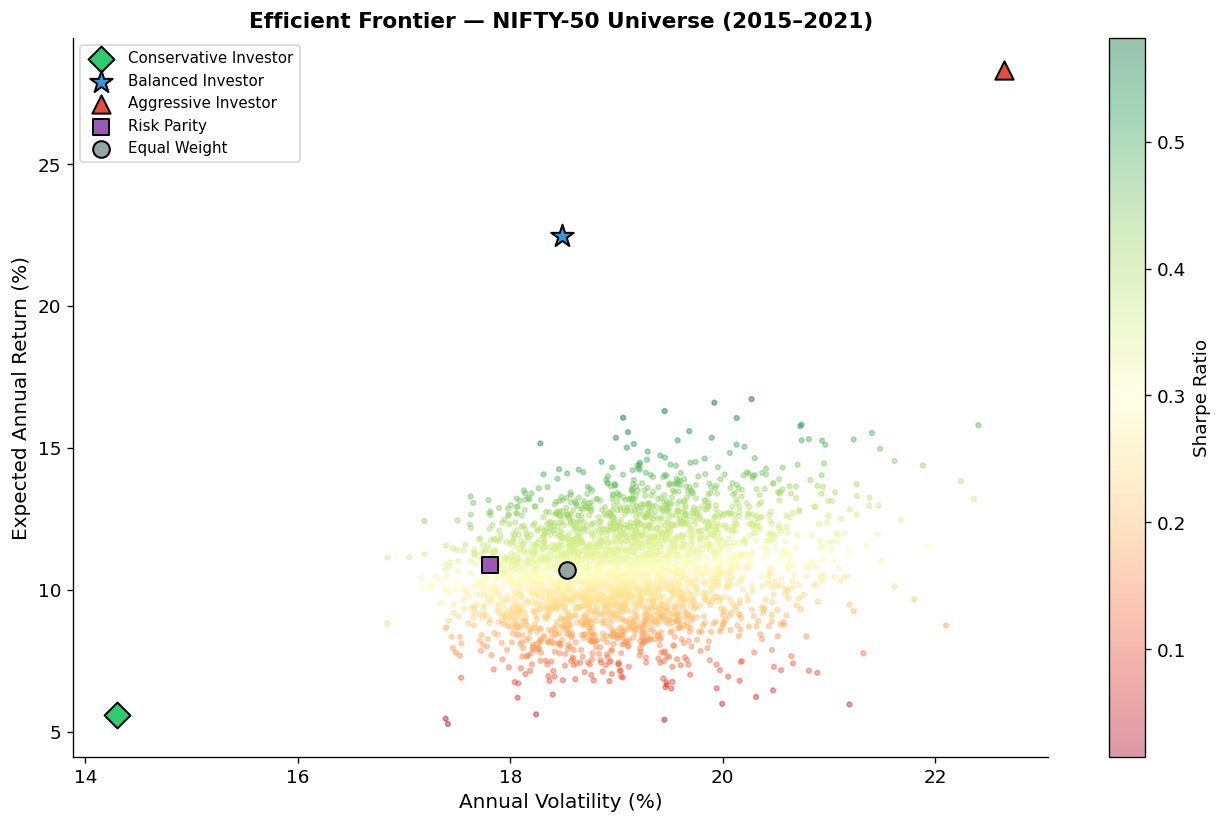

In [6]:
print("Simulating 3000 random portfolios for efficient frontier...")
ef_df = compute_efficient_frontier(prices, n_portfolios=3000)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(ef_df['Volatility']*100, ef_df['Return']*100,
                c=ef_df['Sharpe'], cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Plot each optimised portfolio
markers = {'conservative':'D','balanced':'*','aggressive':'^','risk_parity':'s','equal_weight':'o'}
sizes   = {'conservative':120,'balanced':200,'aggressive':120,'risk_parity':100,'equal_weight':100}
for name, p in portfolios.items():
    ax.scatter(p['annual_volatility']*100, p['expected_annual_return']*100,
               marker=markers.get(name,'o'), s=sizes.get(name,100),
               color=p.get('color','gray'), edgecolors='black', linewidth=1.2, zorder=5,
               label=p['label'])

ax.set_xlabel("Annual Volatility (%)", fontsize=12)
ax.set_ylabel("Expected Annual Return (%)", fontsize=12)
ax.set_title("Efficient Frontier — NIFTY-50 Universe (2015–2021)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('../report/efficient_frontier.png', bbox_inches='tight')
plt.show()

## 6. Discrete Allocation (₹10 Lakh Investment)

In [7]:
from src.portfolio import get_discrete_allocation

INVESTMENT = 1_000_000  # ₹10 Lakhs

print(f"Discrete allocation for ₹{INVESTMENT:,.0f} investment:")
print("=" * 60)

for name in profile_order:
    p = portfolios[name]
    alloc = get_discrete_allocation(p['weights'], prices, INVESTMENT)
    shares = alloc['shares']
    leftover = alloc['leftover_cash']
    
    # Compute invested value
    invested = INVESTMENT - leftover
    
    print(f"\n{p['label']} ({p['strategy']}):")
    print(f"  Stocks allocated: {len(shares)}   Leftover cash: ₹{leftover:,.2f}")
    print(f"  {'Symbol':<15} {'Shares':>8} {'Price (Last)':>14} {'Value':>12}")
    for sym, n_shares in sorted(shares.items(), key=lambda x: -x[1]):
        price = prices[sym].iloc[-1]
        val   = n_shares * price
        print(f"  {sym:<15} {n_shares:>8}  ₹{price:>12,.2f}  ₹{val:>10,.2f}")

Discrete allocation for ₹1,000,000 investment:

Conservative Investor (Minimum Volatility):
  Stocks allocated: 21   Leftover cash: ₹33.05
  Symbol            Shares   Price (Last)        Value
  NTPC                 540  ₹      102.45  ₹ 55,323.00
  POWERGRID            454  ₹      220.05  ₹ 99,902.70
  COALINDIA            413  ₹      133.05  ₹ 54,949.65
  ITC                  331  ₹      202.60  ₹ 67,060.60
  IOC                  139  ₹       90.85  ₹ 12,628.15
  WIPRO                 94  ₹      492.75  ₹ 46,318.50
  CIPLA                 67  ₹      910.35  ₹ 60,993.45
  BHARTIARTL            63  ₹      536.75  ₹ 33,815.25
  HINDUNILVR            42  ₹    2,353.75  ₹ 98,857.50
  HDFCBANK              33  ₹    1,412.30  ₹ 46,605.90
  TCS                   26  ₹    3,035.65  ₹ 78,926.90
  HCLTECH               19  ₹      898.95  ₹ 17,080.05
  ASIANPAINT            17  ₹    2,536.40  ₹ 43,118.80
  SUNPHARMA             17  ₹      654.45  ₹ 11,125.65
  DRREDDY               16  ₹    5,1